<a href="https://colab.research.google.com/github/harveenkaur282-web/ai-ml_labs/blob/main/SIMPLE_LINEAR_REGRESSION_MODEL_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CGPA VS PACKAGE PREDICTION USING SIMPLE LINEAR REGRESSION**

**IMPORT NECESSARY LIBRARIES/DEPENDANCIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, root_mean_squared_error, r2_score


IMPORT/LOAD\ DATASET FROM CSV FILE TO PANDAS DATA FRAMES

In [2]:
placement_data = pd.read_csv('/content/placement.csv')
print(placement_data)

     cgpa  package
0    6.89     3.26
1    5.12     1.98
2    7.82     3.25
3    7.42     3.67
4    6.94     3.57
..    ...      ...
195  6.93     2.46
196  5.89     2.57
197  7.21     3.24
198  7.63     3.96
199  6.22     2.33

[200 rows x 2 columns]


In [3]:
placement_data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [4]:
placement_data.head(10)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
5,7.89,2.99
6,6.73,2.60
7,6.75,2.48
8,6.09,2.31
9,8.31,3.51


In [5]:
placement_data.tail()

,cgpa,package
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96
199,6.22,2.33


In [6]:
placement_data.tail(10)

,cgpa,package
190,6.19,2.69
191,7.28,3.48
192,8.25,3.75
193,4.57,1.94
194,7.89,3.67
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96
199,6.22,2.33


In [7]:
placement_data.shape

(200, 2)

In [8]:
placement_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [9]:
placement_data.isnull().sum()
placement_data.isna().sum()

,0
cgpa,0
package,0


In [10]:
placement_data.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [11]:
X = placement_data['cgpa']
print(X)

0      6.89
1      5.12
2      7.82
3      7.42
4      6.94
       ... 
195    6.93
196    5.89
197    7.21
198    7.63
199    6.22
Name: cgpa, Length: 200, dtype: float64


In [12]:
Y = placement_data['package']
print(Y)

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64


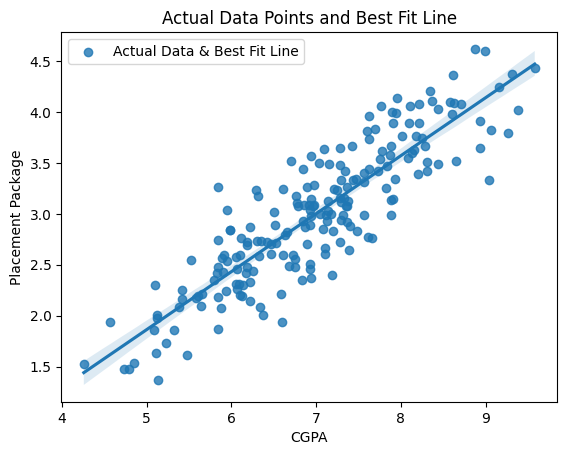

In [13]:
sns.regplot(x=placement_data['cgpa'], y=placement_data['package'], label="Best Fit Line")
plt.xlabel("CGPA")
plt.ylabel("Placement Package")
plt.title("Actual Data Points and Best Fit Line")
plt.legend(["Actual Data & Best Fit Line"])
plt.show()

**DATASET SPLITTING**

In [14]:
[X_train, X_test, Y_train, Y_test] = train_test_split(X,Y, train_size = 0.75, random_state=5)

In [15]:
print('The size of X_train is', X_train.shape)
print('The size of Y_train is', Y_train.shape)
print('The size of X_test is', X_test.shape)
print('The size of Y_test is',Y_test.shape)

The size of X_train is (150,)
The size of Y_train is (150,)
The size of X_test is (50,)
The size of Y_test is (50,)


In [16]:
X_train_2d = X_train.values.reshape(-1,1)
X_test_2d = X_test.values.reshape(-1, 1)
print('The size of training data is', X_train_2d.shape)
print('The size of test data is', X_test_2d.shape)

The size of training data is (150, 1)
The size of test data is (50, 1)


**IMPORT LINEAR REGRESSION MODEL**

In [17]:
linear_model =LinearRegression()

**TRAIN THE MODEL ON TRAINING DATA**

In [18]:
linear_model.fit(X_train_2d, Y_train)

LinearRegression()

In [19]:
m = round(linear_model.coef_[0], 2)
c = round(linear_model.intercept_, 2)
print("The regression coefficient (slope) is", m)
print("The intercept (y) is", c)
print(f"The regression equation is: y = {m}x + {c}")

The regression coefficient (slope) is 0.6
The intercept (y) is -1.16
The regression equation is: y = 0.6x + -1.16


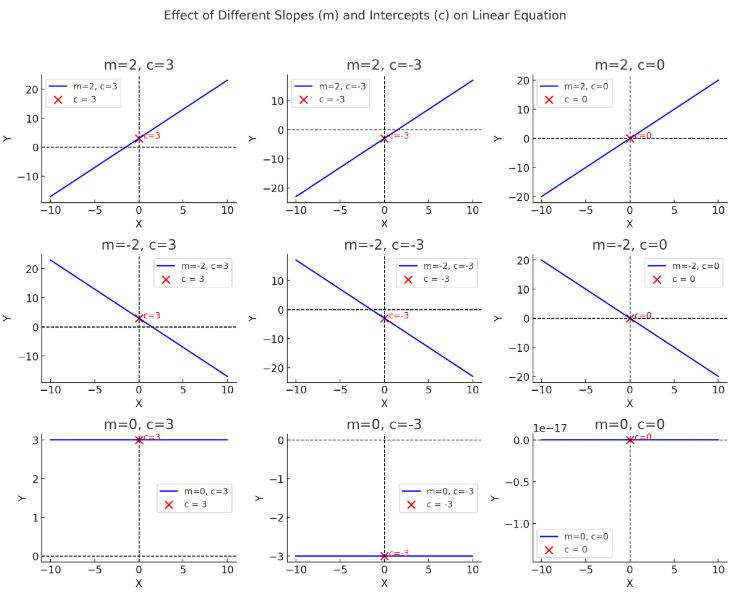


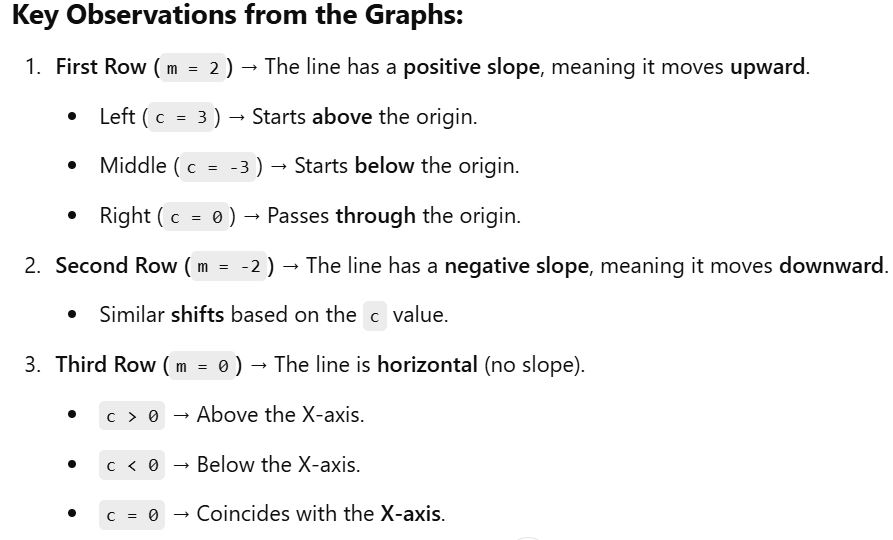



This visualization clearly shows how changing c shifts the line up or down, while m controls the tilt of the line

In [20]:
X_train_data_pred = linear_model.predict(X_train_2d)
X_test_data_pred = linear_model.predict(X_test_2d)

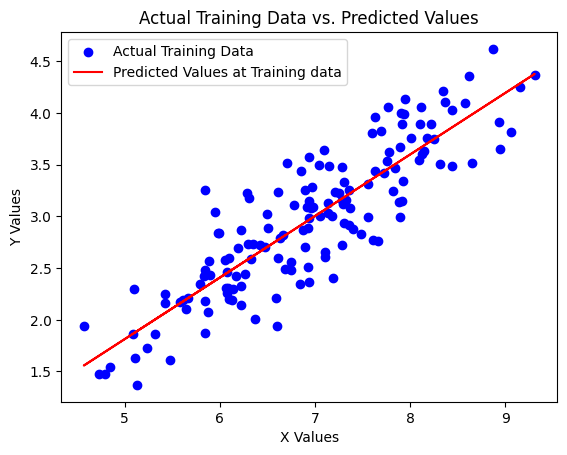

In [21]:
plt.scatter(X_train, Y_train, label="Actual Training Data", color='b')
plt.plot(X_train, X_train_data_pred, color='r', label="Predicted Values at Training data")
plt.xlabel("X Values")
plt.ylabel("Y Values")
plt.title("Actual Training Data vs. Predicted Values")
plt.legend()
plt.show()

 **NOW PREDICTION AND EVALUATION ON TEST DATA**

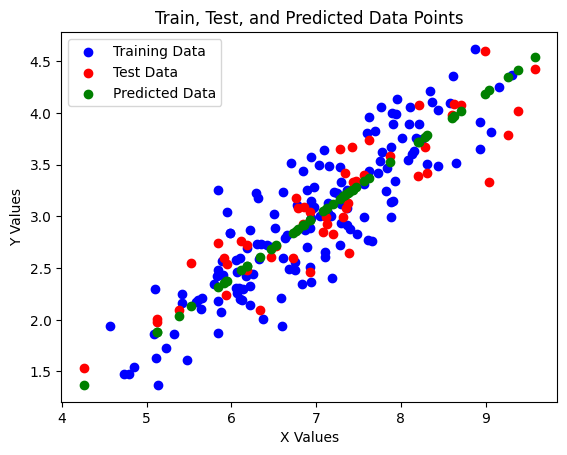

In [22]:
plt.scatter(X_train, Y_train, label="Training Data", color='b')
plt.scatter(X_test, Y_test, label="Test Data", color='r')
plt.scatter(X_test, X_test_data_pred, label="Predicted Data", color='g')
plt.xlabel("X Values")
plt.ylabel("Y Values")
plt.title("Train, Test, and Predicted Data Points")
plt.legend()
plt.show()

**EVALUATE MODEL PERFORMANCE ON TRAINING DATA AND TEST DATA**

In [23]:
r_square_error_training_data = round(r2_score(y_true= Y_train, y_pred = X_train_data_pred), 2)
r_square_error_test_data = round(r2_score(y_true= Y_test, y_pred = X_test_data_pred), 2)
print('The R square error for Training Data is', r_square_error_training_data)
print('The R square error for Test Data is', r_square_error_test_data)

The R square error for Training Data is 0.76
The R square error for Test Data is 0.8


In [24]:
input_data =(7.82)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = linear_model.predict(input_data_reshaped)
print(prediction)

[3.4917465]
